In [50]:
%%HTML
<script src="require.js"></script>

In [51]:
from IPython.display import HTML, display, Markdown, Image
HTML('''<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/jquery.min.js "></script><script>
code_show=true; 
function code_toggle() {
if (code_show){
$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();
} else {
$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();
}
code_show = !code_show
} 
$( document ).ready(code_toggle);</script><form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>
''')

In [52]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# because i need to import this nlng rather than pyfim huhuhu
try:
    import pyfpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfpgrowth"])
    import pyfpgrowth

from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict
import itertools

import os


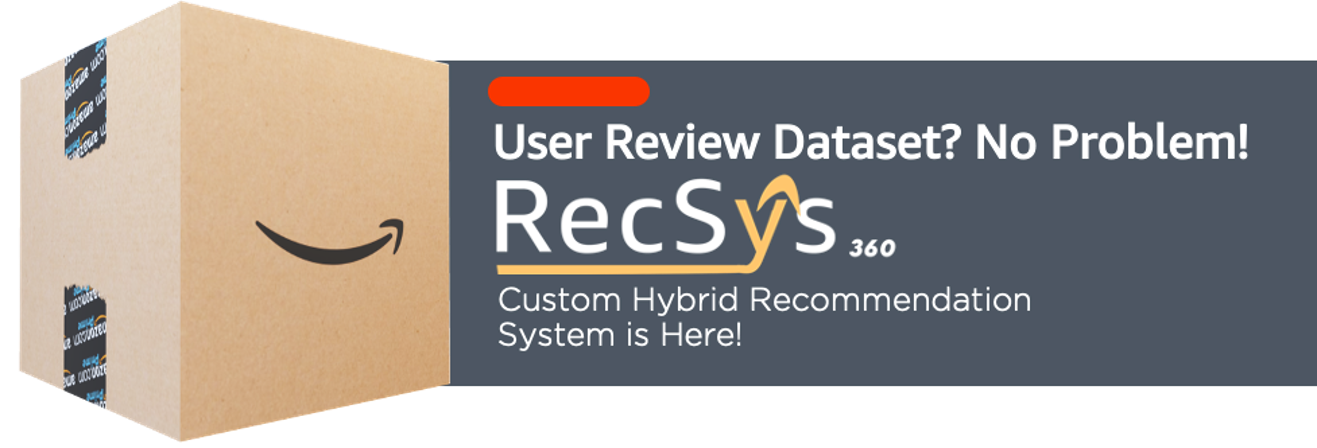

<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">I. Abstract </h1>

Many people struggle to maintain a healthy diet because selecting the right ingredients can be time-consuming and confusing. By allowing groceries to bundle healthy ingredients, nutritious meals become easier, more convenient, and more accessible for everyone. This study aims to identify key ingredient combinations in healthy recipes and explore how these combinations can be bundled in groceries, making nutritious meals more convenient and accessible for everyday cooking.

Using the food-com-recipes dataset containing 231,637 recipes, recipes tagged with “healthy” or “healthy-2” were classified as healthy, while all others were considered non-healthy. Exploratory Data Analysis (EDA) confirmed that healthy recipes contained lower levels of total fat, saturated fat, and sodium, validating their suitability for health-focused analysis. Frequent Itemset Mining (FIM) via the FP-Growth algorithm was applied separately to healthy and non-healthy recipes using a relative minimum support of 0.015 and a minimum confidence of 0.75 to extract meaningful and reliable patterns. The minimum support and confidence thresholds were determined through heuristic hyperparameter tuning, iteratively adjusting values to balance pattern significance and coverage

The analysis revealed 265 frequent itemsets for non-healthy recipes and 227 for healthy recipes. Salt consistently emerged as the most frequent ingredient, with relative supports of 0.365 in non-healthy recipes and 0.389 in healthy ones, confirming its role as a universal base seasoning. Frequent association rules in healthy recipes include `{'active dry yeast'} -> {'salt'}`, `{'warm water'} -> {'salt'}`, and `{'olive oil', 'pepper'} -> {'salt'}`, illustrating ingredient pairings that consistently co-occur. Healthy recipes also featured unique combinations such as vegetable oil (relative support of 0.057) and whole wheat flour (relative support of 0.025), suggesting substitutions that reduce saturated fat and improve nutritional quality. A Jaccard similarity index of 0.45 between frequent ingredient combinations in non-healthy and healthy recipes indicates moderate overlap, highlighting distinct health-oriented patterns while maintaining familiar flavors.

Based on these findings, Groceries can leverage the study’s findings to promote healthier recipes by highlighting high-confidence ingredient pairings, in bundles or recipe-based displays, while avoiding misleading “healthy” labels for ingredients like salt, sugar, or butter. Retailers can also encourage smarter substitutions, such as using honey for sugar or olive oil for butter, to maintain flavor while improving nutritional quality. Future research could enhance these insights by integrating nutritional attributes directly into the itemset mining process to identify ingredient combinations that are both frequent and nutritionally meaningful.

<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

Despite widespread awareness of healthy eating, many people struggle to translate knowledge into action because selecting and combining nutritious ingredients can be time-consuming and overwhelming. Simplifying this process, such as through thoughtfully designed ingredient bundles, has the potential to make healthy meals more accessible and practical for everyday life. The effectiveness of bundling healthy ingredients has been demonstrated in prior research, highlighting its potential relevance for promoting nutritious eating. For example, Stein found that providing pre‑measured ingredient bundles alongside recipe tastings significantly increased the selection of healthier foods (2019). Clients exposed to the bundles were several times more likely to choose these healthy items compared with those who received recipe tastings alone. This evidence underscores the practical impact of simplifying ingredient selection, supporting the importance of investigating ingredient combinations in healthy recipes to inform initiatives like general healthy grocery bundles.

In line with this, the study aims to inform the development of grocery-friendly bundles of healthy ingredients, guiding the creation of recipes that are both nutritious and convenient for consumers. **The core problem is identifying which ingredients combinations are most common in healthy recipes and whether these recipes are sufficiently distinct from non-healthy recipes**. Reducing the number of unique ingredients allows consumers to prepare nutritious meals without needing to purchase a wide variety of items or make frequent trips to the store. Using Frequent Itemset Mining, core ingredients that can serve as a reliable base for daily meals, simplifying the process of consistently cooking healthy dishes were identified. The objectives are then three-fold:
1. Validate recipe healthiness through exploratory data analysis of ingredients and health-related tags
2. Find frequent ingredient combinations and association rules using Frequent Itemset Mining for healthy recipes and for non-healthy recipes separately
3. Compare healthy and non-healthy recipes by analyzing and contrasting their frequent ingredient sets.


<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">III. METHODOLOGY</h1>

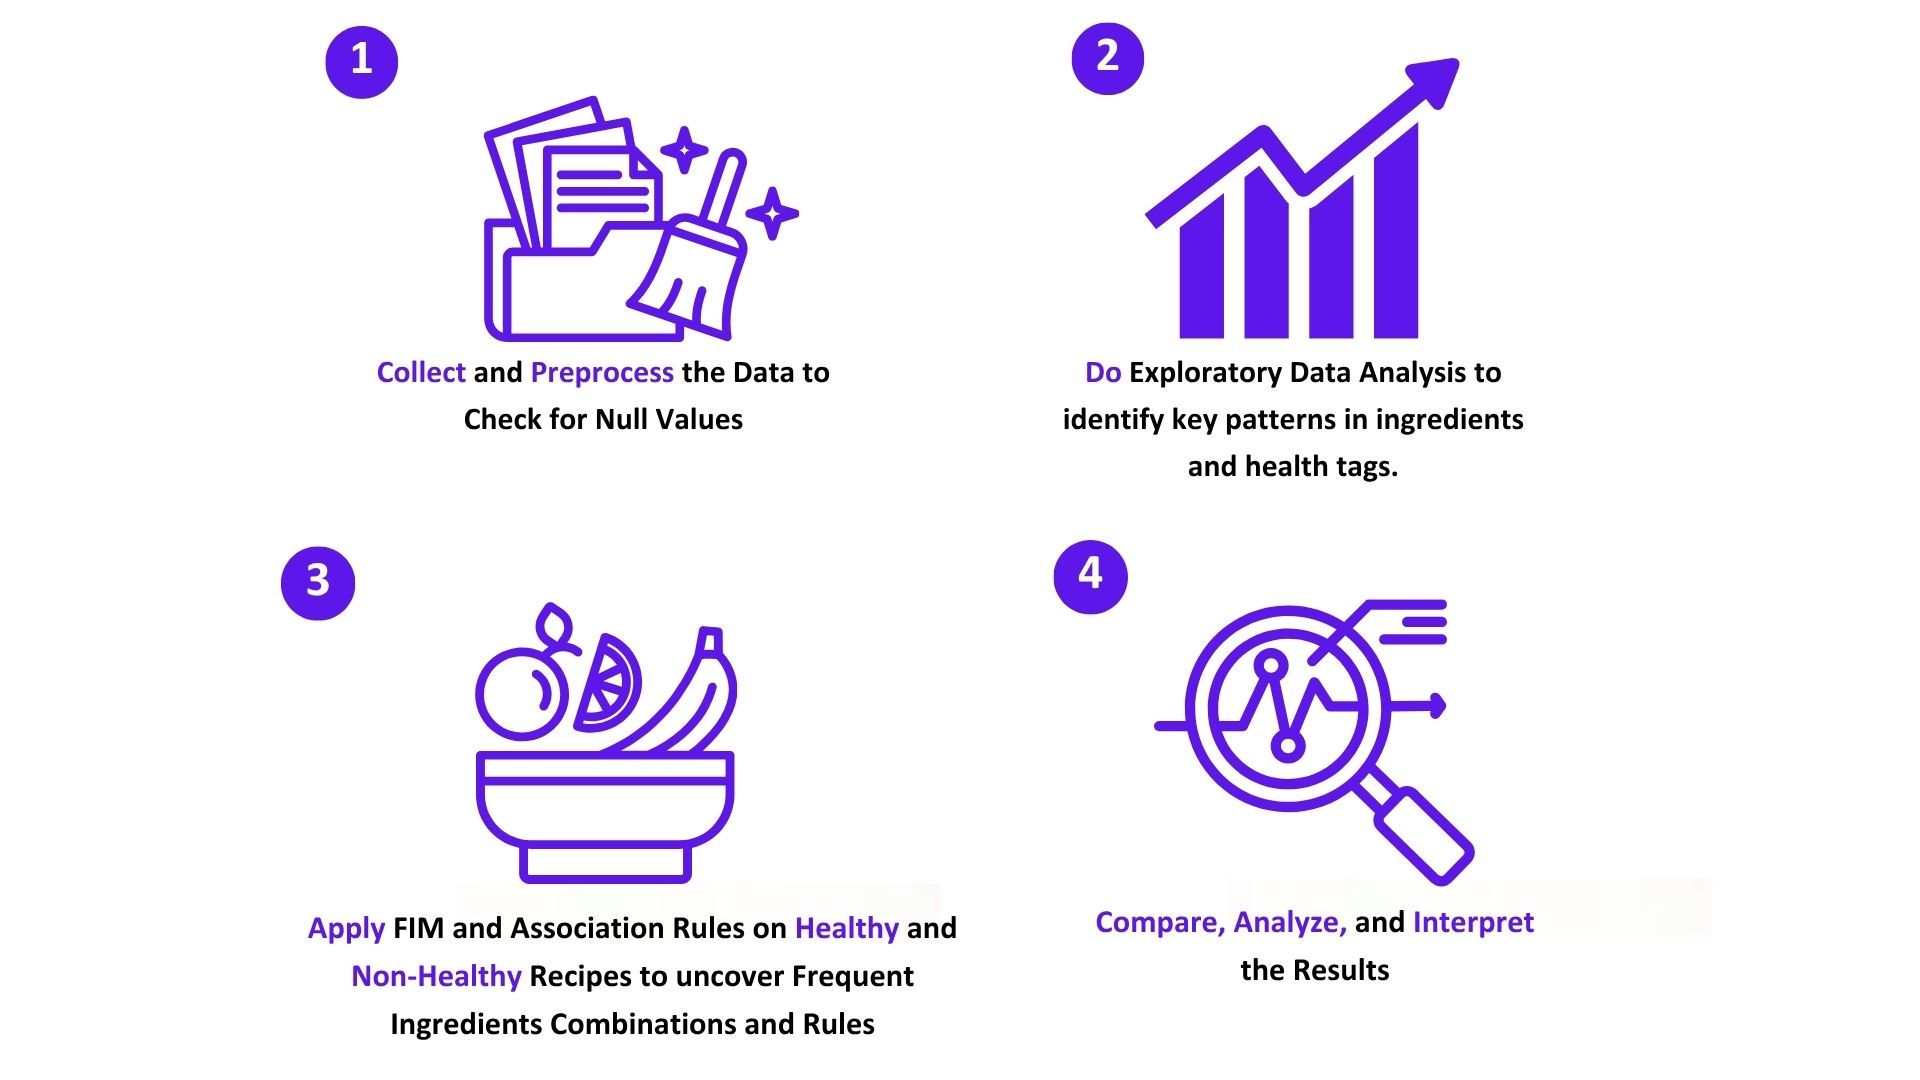
<left><span style="font-size:14px"><b>Figure 1. </b>Methodology</span></left>

*3.1 Collect and Preprocess the Data to Check for Null Values*

The data was collected and checked for null values in relevant columns, and none were found. Irrelevant columns were dropped while the relevant columns for analysis are discussed later.

*3.2 Do Exploratory Data Analysis to identify key patterns in ingredients and health tags. (EDA)*

The EDA focused on two main objectives. First, the most common ingredients across all recipes were identified using a bar chart to show frequency patterns. Second, healthy recipes, which were defined as those with a tag containing the word “health” (healthy or healthy-2), were compared to non-healthy recipes using histograms of nutritional values to check if they are indeed healthier. Healthy foods comprise about 20% of the sample. 

*3.3 Apply FIM and Association Rules on Healthy and Non-Healthy Recipes to uncover Frequent Ingredients Combinations and Rules*

Frequent Itemset Mining (FIM) and association rule analysis were applied separately to healthy and non-healthy recipes to uncover common ingredient combinations and relationships. This approach identifies which ingredients tend to appear together and reveals patterns specific to each category, helping to understand typical recipe structures and dietary trends in the dataset. The python module used is `pyfpgrowth` because it is readily available via `pip install`, which allowed the analysis to proceed while Jojie was unavailable.

*3.4 Compare, Analyze, and Interpret the Results*

The frequent ingredient combinations of healthy and non-healthy recipes were compared using the Jaccard index to see if they are sufficiently different. Based on the frequent itemsets found, ingredient-based recommendations were generated to suggest substitutions or combinations that could make recipes healthier.


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">IV. Collect and Preprocess the Data to Check for Null Values</h1>

The data collection section involves three key steps:
1. Identifying the data source;
2. Collecting and storing the data as a CSV; and
3. Describing the data.

<h2 style="color:#ff9a00">A. Data Source</h2>

The team utilized the food-com-recipes dataset, which is publicly available through the ‘jojie-collected’ repository in the /mnt/data/public directory maintained by the Asian institute of Management. The dataset, located at `/mnt/data/public/food-com-recipes/RAW_recipes.csv`, contains various recipes and reviews.


<h2 style="color:#ff9a00">B. Data Collection and Database Creation</h2>

While the team retrieved the data using the Jojie public dataset repository, it is also important to acknowledge the original data source and its collection method. The food-com-recipes dataset is a publicly available collection of over 180 thousand recipes and 700 thousand recipe reviews which covers 18 years of user interactions and uploads from the website Food.com, previously known as Genius Kitchen. The dataset was accessed in CSV format (294.52 MB) and processed using the Pandas library in Python for further analysis.


<h2 style="color:#ff9a00">C. Data Description</h2>

The following features were used and considered relevant for this report:

The following features are contained in the food-com-recipes Dataset with a shape of 231637 and 12 columns but we will only focus on 3 important columns listed in Table 1

<div align="center">

| Feature     | Description                                                                 | Data Type      |
|------------|-----------------------------------------------------------------------------|---------------|
| Tags       | List of words and phrases to describe the recipe                             | List (string) |
| Nutrition  | List of Nutritional Values — calories, total fat, sugar, sodium, protein, saturated fat, and carbohydrates | List (integer) |
| Ingredients | List of ingredients used in the recipe                                      | List (string) |

<left><span style="font-size:14px"><b>Table 1. </b>Features from food-com-recipes</span></left>

</div>

<h2 style="color:#ff9a00">D. Preprocess the Data</h2>

As shown in Table 2, no null values were removed because the relevant columns are complete. Nulls in the description column merely indicate that a customer chose not to provide feedback and do not affect the analysis. Similarly, one recipe, which does not have a name, still has a non-empty ingredients and tag list, so it was still usable. Additionally, because the dataset was originally stored in a CSV file, the nutrition, tags, and ingredients columns were encoded as strings instead of actual lists. These were therefore converted into proper list formats for accurate processing.

In [ ]:
#folder_path = "/mnt/data/public/food-com-recipes/RAW_recipes.csv"
# Load the data and save it into the variable df
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path)

In [ ]:
# Inspect the null values if there are any
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ["Column", "Number of Nulls"]

# Display results 
display(null_counts)
display(Markdown("**Table 2.** Number of Null Values per Column"))


,Column,Number of Nulls
0,name,1
1,id,0
2,minutes,0
3,contributor_id,0
4,submitted,0
5,tags,0
6,nutrition,0
7,n_steps,0
8,steps,0
9,description,4979


**Table 2.** Number of Null Values per Column

In [ ]:
# Convert the string tags inton lists
df['tags'] = df['tags'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

# Convert the string ingredients inton lists
df['ingredients'] = df['ingredients'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

<a id='Exploration'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">V. Exploratory Data Analysis</h1>

Across all recipes, salt, butter, and sugar are the most frequently used ingredients, followed by staples like onion, water, eggs, and olive oil. Common items such as flour, milk, garlic, and pepper indicate a reliance on basic seasonings and foundational components. This pattern reflects typical everyday cooking and helps identify core ingredients for meal planning.


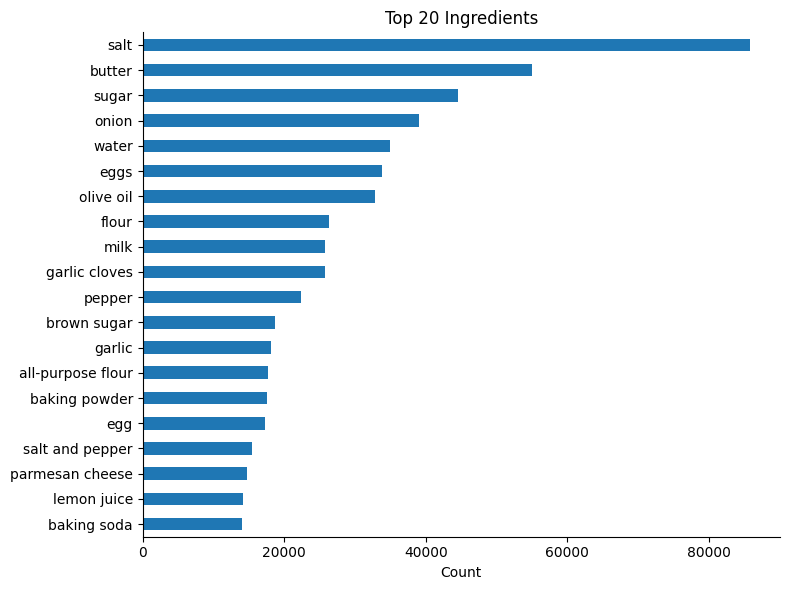

**Figure 2.** Top 20 Ingredients Over All Recipes

In [ ]:
# compute top 20 ingredients
top_ingredients = (
    df["ingredients"]
    .explode()
    .value_counts()[:20]
    .sort_values(ascending=True)
)

# Plot the bar chart
ax = top_ingredients.plot(kind="barh", figsize=(8, 6))
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Top 20 Ingredients")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save the figure
plt.tight_layout()
plt.savefig("figures/top_20_ingredients.png", dpi=300)
plt.show()

display(Markdown("**Figure 2.** Top 20 Ingredients Over All Recipes"))

A food is considered healthy if it has a tag containing the word “health,” which in this dataset corresponds to `healthy` or `healthy-2`. Recipes with at least one such tag are included in the df_healthy subset for analysis. There are 45,188 healthy recipes, accounting for 20% of the dataset.

After defining healthy foods, a sanity check was performed by comparing the distribution of nutritional values between the non-healthy and healthy subsets. Total fat, saturated fat, and sodium are lower in the healthy subset compared to the non-healthy subset, which aligns with dietary recommendations for reducing the risk of cardiovascular disease, obesity, and other diet-related conditions (American Heart Association, 2024; U.S. Department of Agriculture & U.S. Department of Health and Human Services, 2025). This confirms that filtering by “health”-related tags is sufficient for analysis.


In [62]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Create the tags presence matrix
mlb = MultiLabelBinarizer()
tags_matrix = mlb.fit_transform(df['tags'])
df_tags_matrix = pd.DataFrame(
    tags_matrix, columns=mlb.classes_, index=df.index
)

# Identify all tags containing "health"
health_related_tags = [
    col for col in df_tags_matrix.columns if 'health' in col.lower()
]

# Create boolean mask for healthy-tagged foods
is_health_tag = df_tags_matrix[health_related_tags].any(axis=1)

# Filter healthy and non-healthy foods
df_healthy = df[is_health_tag]
df_non_healthy = df[~is_health_tag]

# Save indices of healthy foods to CSV
df_healthy.index.to_series().to_csv(
    'data/is_healthy_food.csv', index=False, header=False
)

# Count healthy and non-healthy recipes
healthy_count = is_health_tag.sum()
non_healthy_count = (~is_health_tag).sum()
total_count = len(df)

# Compute percentages
healthy_pct = (healthy_count / total_count) * 100
non_healthy_pct = (non_healthy_count / total_count) * 100

# Display results
print(f"Total recipes: {total_count:,}")
print(f"Healthy recipes: {healthy_count:,} ({healthy_pct:.2f}%)")
print(f"Non-healthy recipes: {non_healthy_count:,} ({non_healthy_pct:.2f}%)")

Total recipes: 231,637
Healthy recipes: 45,188 (19.51%)
Non-healthy recipes: 186,449 (80.49%)


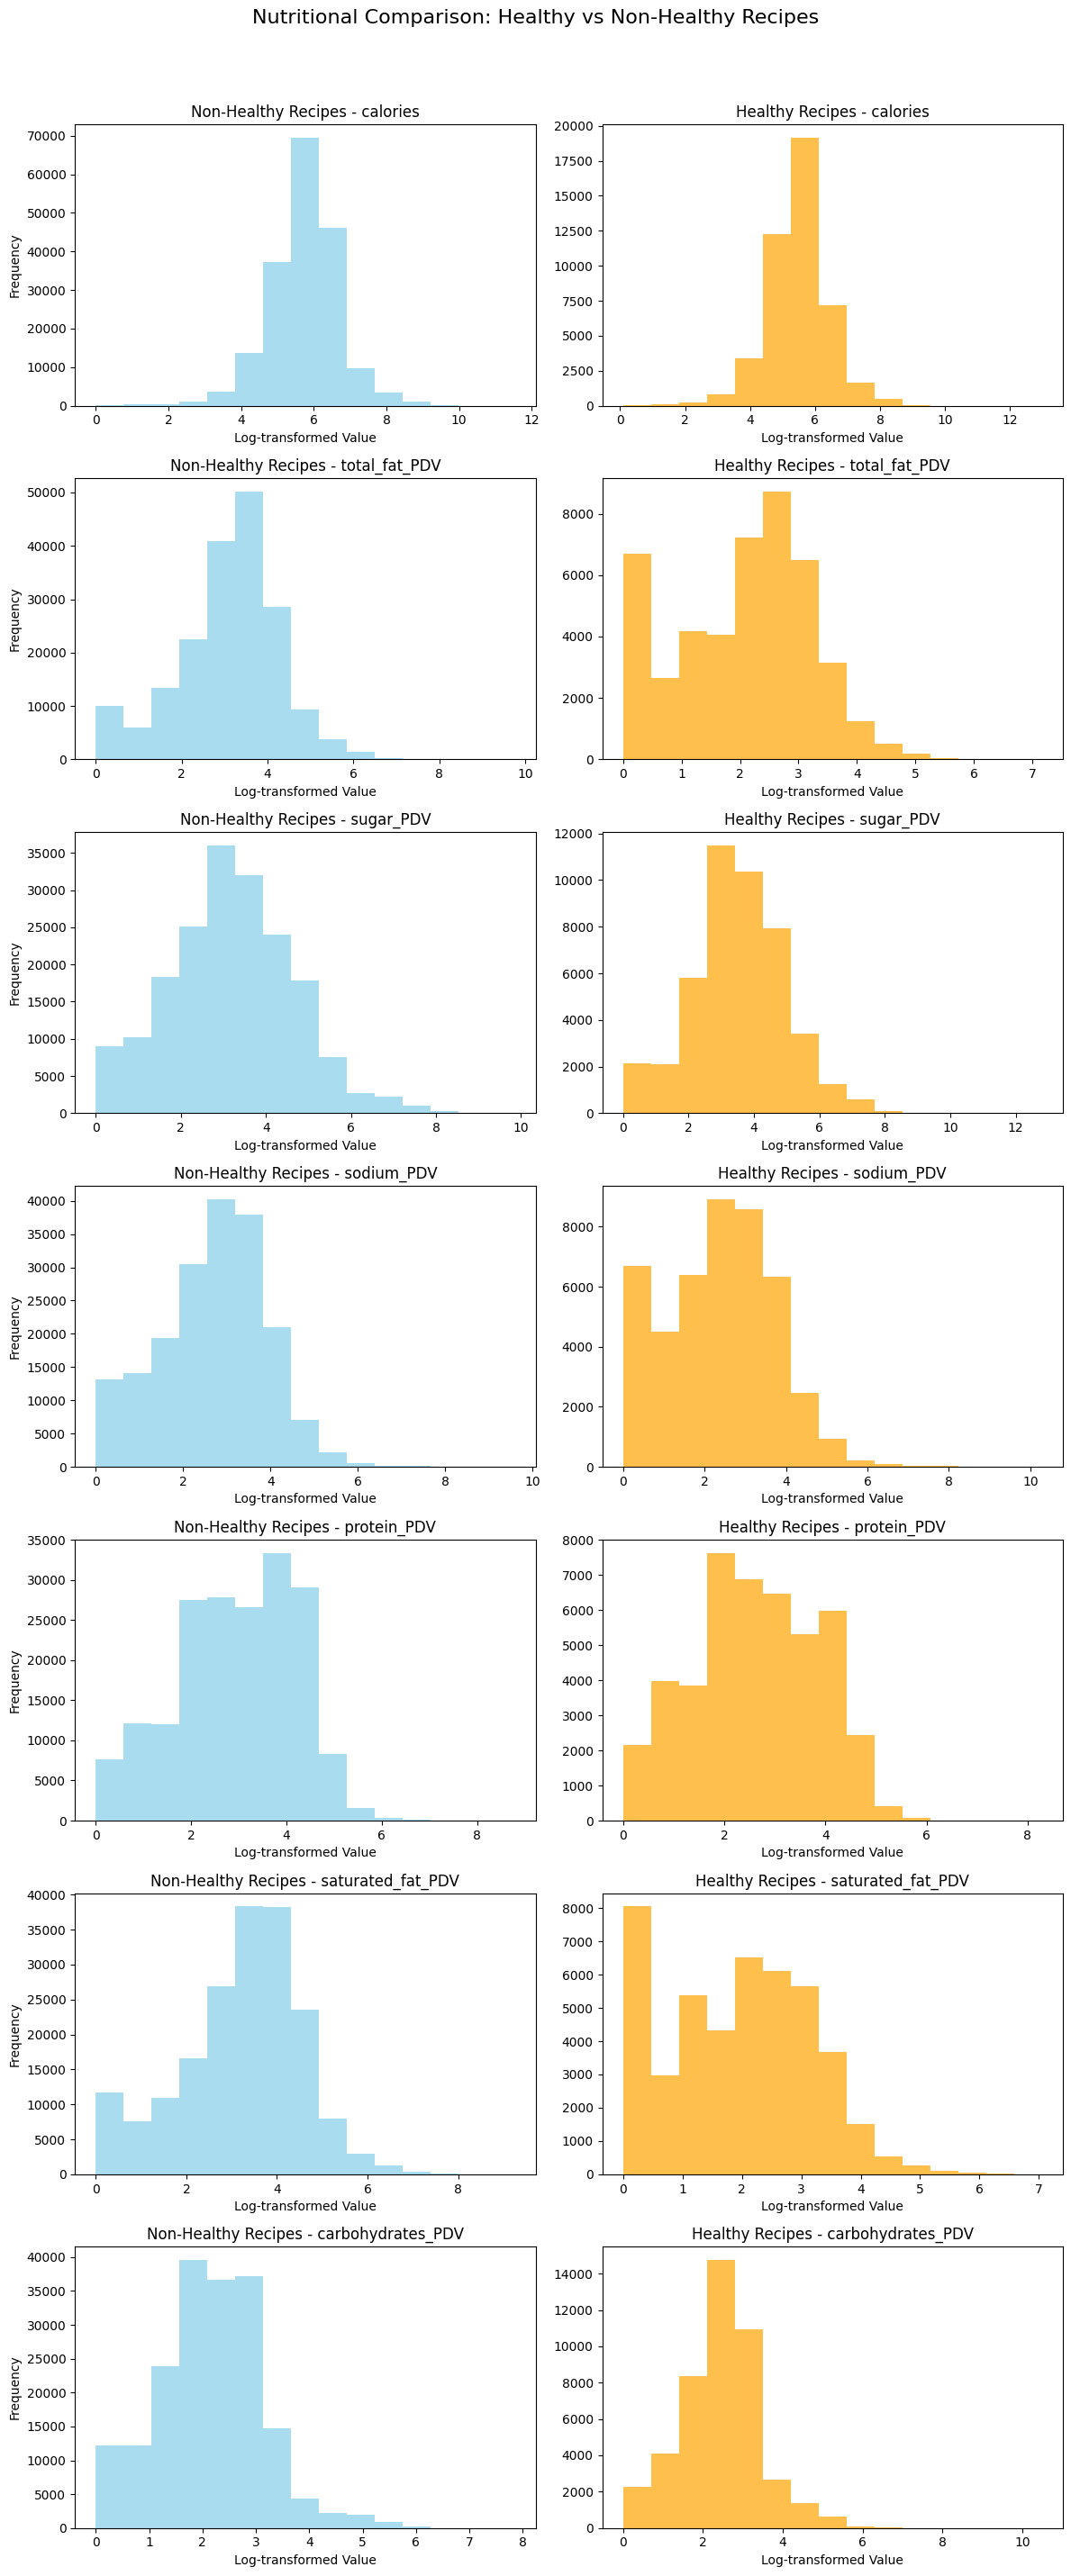

**Figure 3.** Nutritional Comparison between Non-Healthy and Healthy Recipes

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import pandas as pd

# List of nutrition columns to extract from the 'nutrition' dictionary
nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

# Convert nutrition dictionaries into separate DataFrames
df_healthy_nutritions = df_healthy["nutrition"].apply(pd.Series)
df_healthy_nutritions.columns = nutrition_cols

df_non_healthy_nutritions = df_non_healthy["nutrition"].apply(pd.Series)
df_non_healthy_nutritions.columns = nutrition_cols

# Plot comparison of healthy vs non-healthy recipes for each nutrition column
selected_cols = nutrition_cols
fig, axes = plt.subplots(
    nrows=len(selected_cols),
    ncols=2,
    figsize=(12, 4 * len(selected_cols))
)
fig.suptitle(
    "Nutritional Comparison: Healthy vs Non-Healthy Recipes",
    fontsize=16,
    y=1.02
)

for i, col in enumerate(selected_cols):
    # Plot histogram for non-healthy recipes
    axes[i, 0].hist(
        np.log1p(df_non_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="skyblue"
    )
    axes[i, 0].set_title(f"Non-Healthy Recipes - {col}")
    axes[i, 0].set_xlabel("Log-transformed Value")
    axes[i, 0].set_ylabel("Frequency")

    # Plot histogram for healthy recipes
    axes[i, 1].hist(
        np.log1p(df_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="orange"
    )
    axes[i, 1].set_title(f"Healthy Recipes - {col}")
    axes[i, 1].set_xlabel("Log-transformed Value")

plt.tight_layout()
plt.show()

display(
    Markdown(
        "**Figure 3.** Nutritional Comparison between Non-Healthy and "
        "Healthy Recipes"
    )
)

<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">VI. Apply FIM and Association Rules on Healthy and Non-Healthy Recipes to uncover Frequent Ingredients Combinations and Rules</h1>

<a id='Clustering'></a>
<h2 style="color:#ff9a00">A. Apply FIM to Ingredients for Non-Healthy Food</h2>

Frequent Itemset Mining (FIM) was separately applied to non-healthy and healthy recipes to identify frequent ingredient combinations. FP-Growth was chosen because it is efficient for large datasets, avoiding the generation of candidate itemsets that do not actually occur in the data and ensuring that only relevant frequent itemsets are considered. 

In order to know the proper values we should use for our parameters, particularly minimum relative support and minimum confidence, we did hyperparameter tuning. We used heuristic or exploratory tuning where the distribution of itemset supports is visualized using a histogram, and a reasonable threshold is chosen using the elbow method. This approach was chosen because it balances coverage and noise. Setting the threshold too low would produce many rare itemsets while setting it too high will miss meaningful ingredient combinations. Through the elbow point, we can get the parameters that capture the most frequent and meaningful combinations without being overwhelmed by irrelevant patterns. We ensured to start from a non-zero value (0.1%) to avoid generating too many itemsets.

As seen from Figure 4, 0.015 is the point where support begins to decrease sharply, indicating that this is the most appropriate minimum support value to focus on itemsets that appear in a sufficient number of recipes to be meaningful, while filtering out combinations that are too infrequent to provide useful insights.


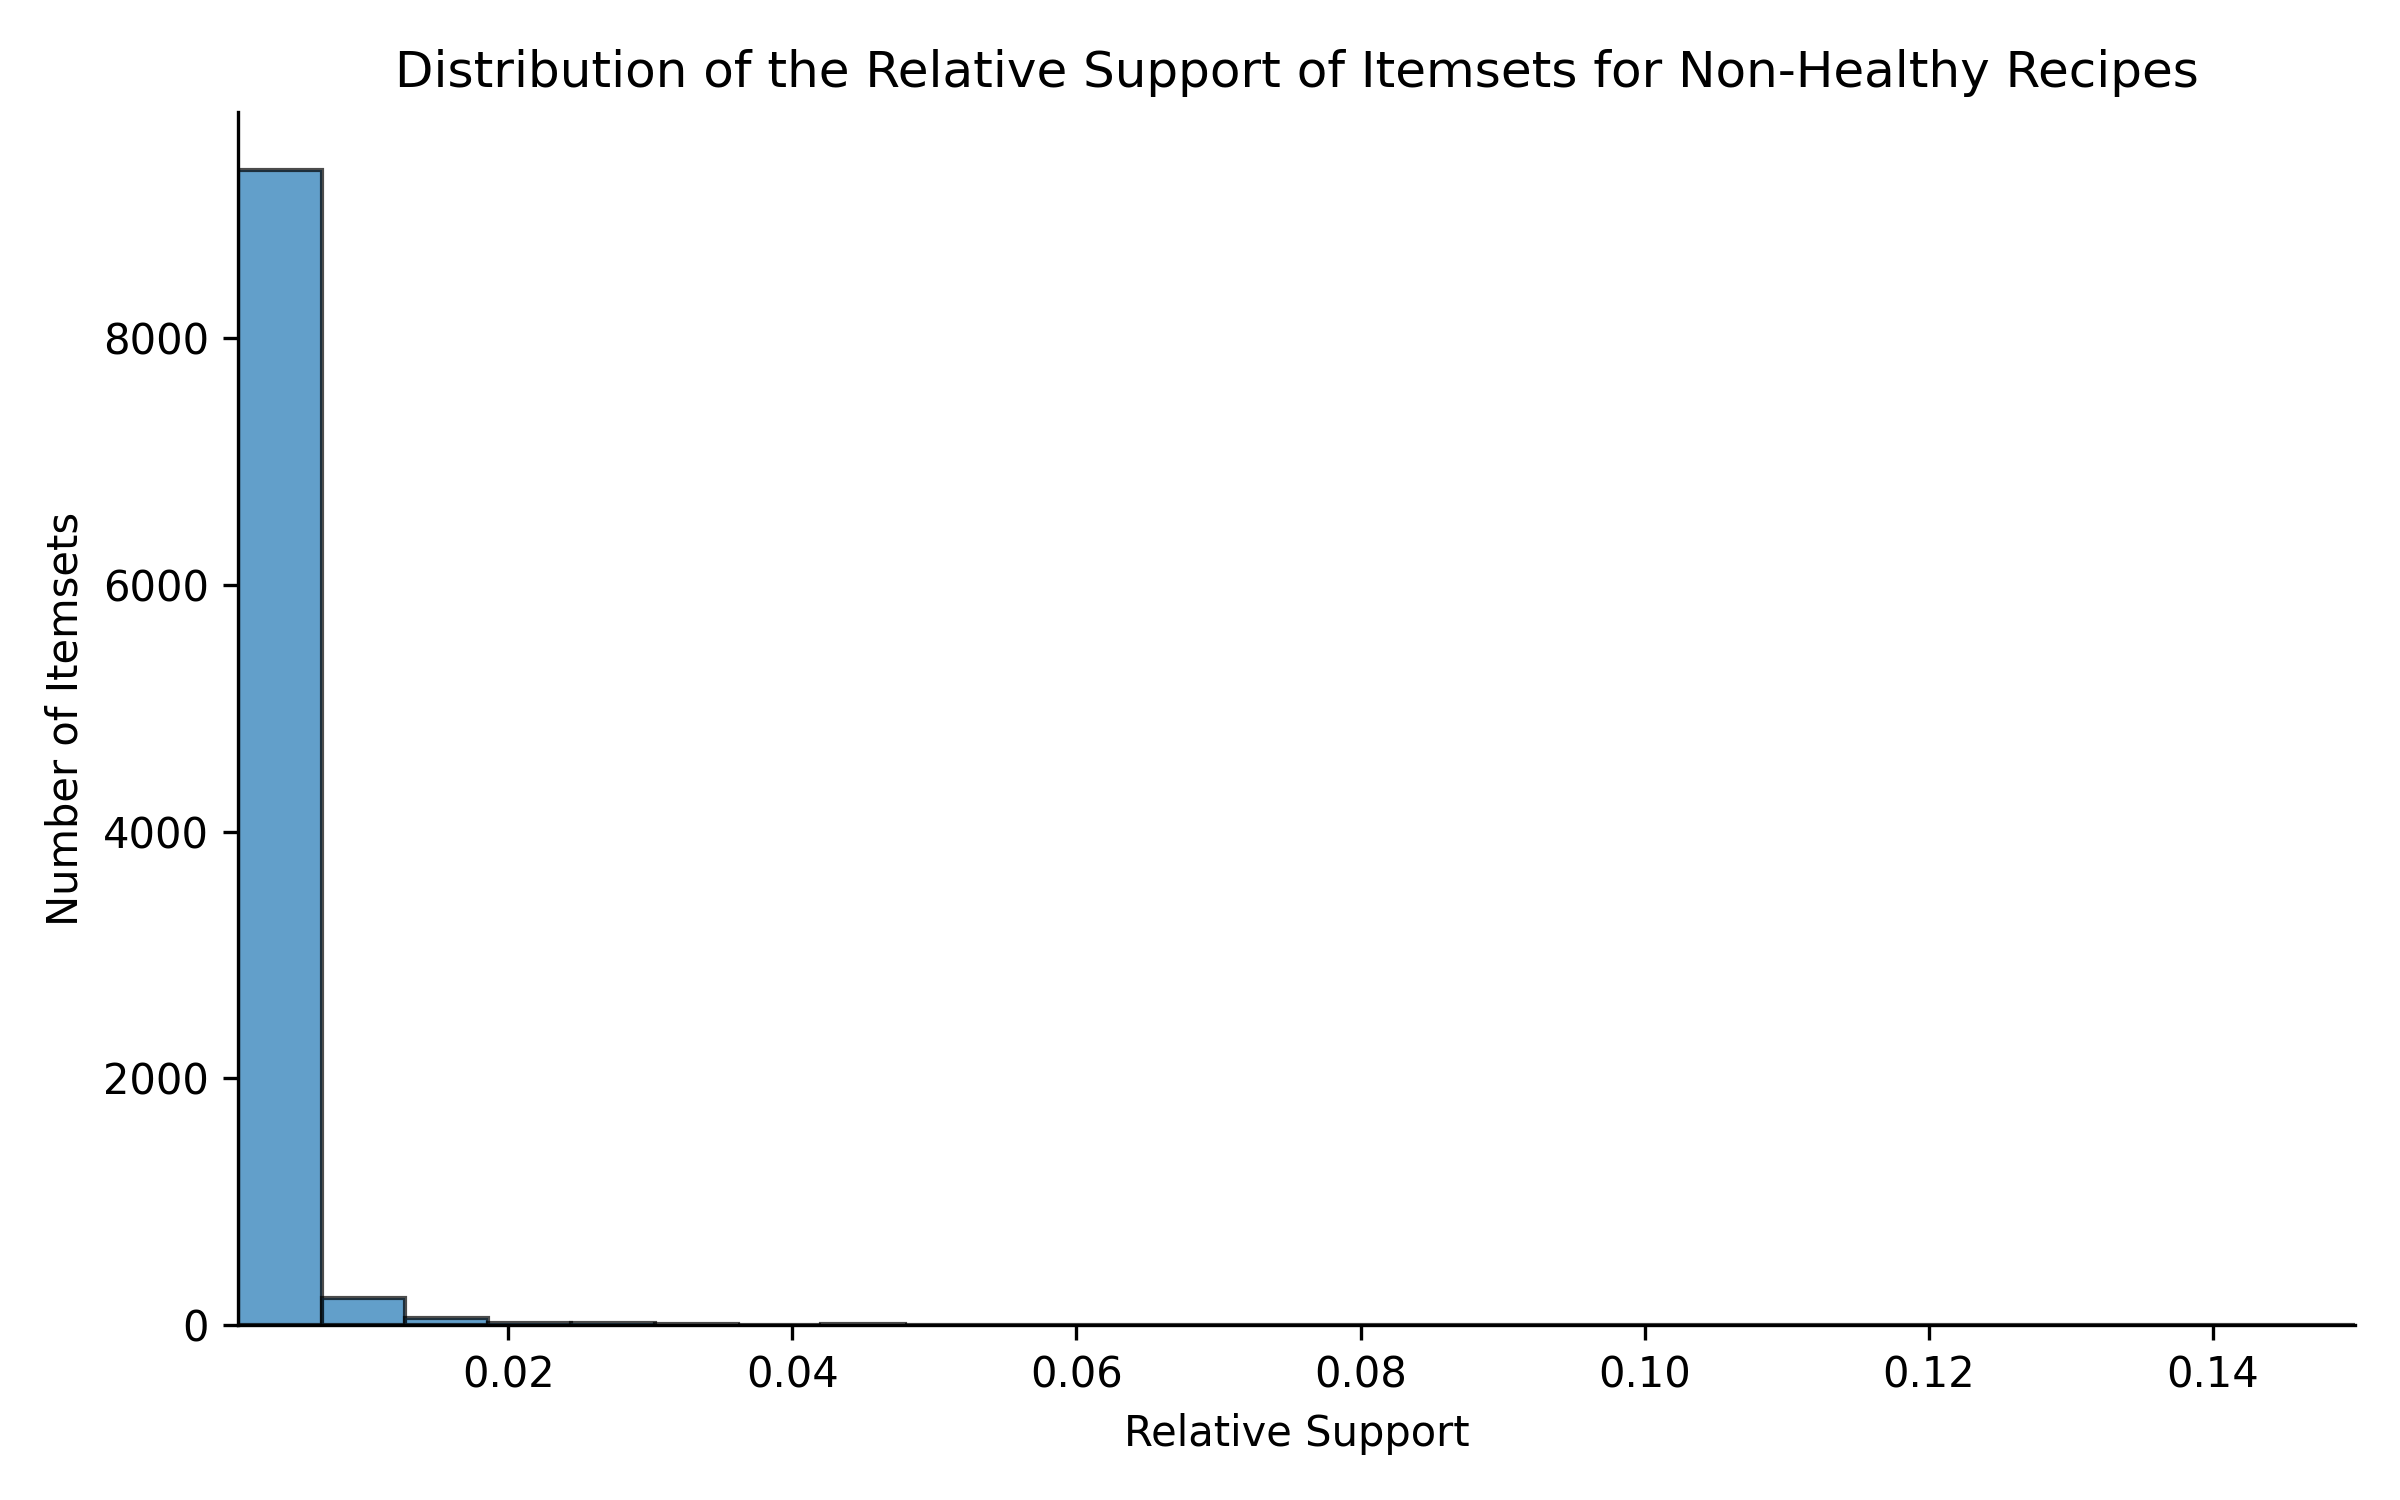

**Figure 4.** Distribution of the Relative Support of Itemsets for Non-Healthy Recipes

In [65]:
file_path = 'figures/relsup_non_healthy.png'

if os.path.exists(file_path):
    # If file exists, just display it
    display(Image(filename=file_path))
else:
    # --- Prepare transactions (list of ingredient lists) ---
    transactions = df_non_healthy['ingredients'].tolist()

    # --- Set minimum support threshold ---
    min_support = 0.001  # you can adjust this

    # --- Compute absolute minimum support count ---
    minsup_count = max(1, int(len(transactions) * min_support))

    # --- Find frequent itemsets ---
    patterns = pyfpgrowth.find_frequent_patterns(transactions, minsup_count)

    # --- Convert to DataFrame ---
    itemset_freq = pd.DataFrame({
        'itemset': list(patterns.keys()),
        'count': list(patterns.values())
    })
    itemset_freq['support'] = itemset_freq['count'] / len(df)

    # --- Filter supports (just to zoom in) ---
    itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

    # --- Show summary statistics ---
    print(itemset_freq['support'].describe())

    # --- Plot histogram ---
    plt.figure(figsize=(8, 5))
    plt.hist(itemset_freq['support'], bins=50, edgecolor='black', alpha=0.7)
    plt.title(
    "Distribution of the Relative Support of Itemsets "
    "for Non-Healthy Recipes"
    )
    plt.xlabel("Relative Support")
    plt.ylabel("Number of Itemsets")
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # --- Adjust x-axis and layout ---
    plt.xlim(0.001, 0.15)
    plt.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.savefig(file_path, dpi=300)
    plt.show()

display(
    Markdown(
        "**Figure 4.** Distribution of the Relative Support of "
        "Itemsets for Non-Healthy Recipes"
    )
)


In [44]:
# --- Parameters ---
min_support = 0.015
min_confidence = 0.75

# --- Step 1: Compute minsup count ---
num_transactions = len(df_non_healthy['ingredients'])
minsup_count = max(1, int(num_transactions * min_support))

# --- Step 2: Find frequent itemsets ---
freq_itemsets = pyfpgrowth.find_frequent_patterns(
    df_non_healthy['ingredients'].to_list(),
    minsup_count
)

# --- Step 3: Generate association rules ---
rules = pyfpgrowth.generate_association_rules(freq_itemsets, min_confidence)

# --- Step 4: Add support & lift for each rule ---
def get_support(itemset):
    """Return support of an itemset."""
    return freq_itemsets.get(itemset, 0) / num_transactions

lifted_rules = []
for antecedent, (consequent, confidence) in rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)
    if consequent_support == 0:
        continue
    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Step 5: Sort rules by confidence (and lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Step 6A: Display top 10 frequent itemsets ---
print("=== Top 10 Frequent Itemsets ===")
top10_itemsets = sorted(
    freq_itemsets.items(), key=lambda x: x[1], reverse=True
)[:10]
for i, (itemset, support_count) in enumerate(top10_itemsets, start=1):
    rel_support = support_count / num_transactions
    print(f"{i}. {set(itemset)} (support = {rel_support:.3f})")


=== Top 10 Frequent Itemsets ===
1. {'salt'} (support = 0.365)
2. {'butter'} (support = 0.262)
3. {'butter', 'salt'} (support = 0.119)
4. {'sugar', 'salt'} (support = 0.095)
5. {'eggs', 'salt'} (support = 0.086)
6. {'salt', 'pepper'} (support = 0.082)
7. {'flour', 'salt'} (support = 0.073)
8. {'salt', 'onion'} (support = 0.072)
9. {'eggs', 'butter'} (support = 0.071)
10. {'butter', 'sugar'} (support = 0.070)


Once the relative minimum support was chosen, 265 frequent combinations were found. The top 10 most frequent itemsets for non-healthy recipes are listed in Table 3. From the FIM, salt dominates across most combinations, appearing either alone or paired with other foundational ingredients like butter, sugar, eggs, and flour. This suggests that salt acts as a universal component in non-healthy recipes, enhancing flavor and preserving food.


<div align="center">

| Rank | Ingredients         | Support | Relative Support |
| ---- | ------------------- | ------- | ---------------- |
| 1    | {'salt'}            | 68,134  | 0.365430         |
| 2    | {'butter'}          | 48,934  | 0.262452         |
| 3    | {'butter', 'salt'}  | 22,210  | 0.119121         |
| 4    | {'salt', 'sugar'}   | 17,630  | 0.094557         |
| 5    | {'eggs', 'salt'}    | 16,087  | 0.086281         |
| 6    | {'pepper', 'salt'}  | 15,243  | 0.081754         |
| 7    | {'flour', 'salt'}   | 13,535  | 0.072594         |
| 8    | {'onion', 'salt'}   | 13,410  | 0.071923         |
| 9    | {'butter', 'eggs'}  | 13,293  | 0.071296         |
| 10   | {'butter', 'sugar'} | 13,050  | 0.069992         |

**Table 3**. Top 10 Most Frequent Ingredients Combinations for Non-Healthy Recipes

</div>

In [66]:
# Display top 10 association rules with confidence and lift
print("\n=== Top 10 Association Rules ===")
top10_rules = lifted_rules[:10]

for i, (antecedent, consequent, confidence, lift) in enumerate(
    top10_rules, start=1
):
    print(
        f"{i}. {set(antecedent)} -> {set(consequent)} "
        f"(confidence = {confidence:.2f}, lift = {lift:.2f})"
    )



=== Top 10 Association Rules ===
1. {'active dry yeast'} -> {'salt'} (confidence = 0.92, lift = 2.35)
2. {'warm water'} -> {'salt'} (confidence = 0.87, lift = 2.24)
3. {'olive oil', 'pepper'} -> {'salt'} (confidence = 0.86, lift = 2.20)
4. {'onion', 'pepper'} -> {'salt'} (confidence = 0.83, lift = 2.12)
5. {'baking powder', 'butter'} -> {'salt'} (confidence = 0.82, lift = 2.11)
6. {'sugar', 'all-purpose flour'} -> {'salt'} (confidence = 0.82, lift = 2.09)
7. {'baking powder', 'all-purpose flour'} -> {'salt'} (confidence = 0.81, lift = 2.09)
8. {'baking powder', 'milk'} -> {'salt'} (confidence = 0.79, lift = 2.03)
9. {'baking powder', 'sugar'} -> {'salt'} (confidence = 0.79, lift = 2.01)
10. {'sugar', 'baking powder', 'flour'} -> {'salt'} (confidence = 0.78, lift = 2.01)


For the association rules, a minimum confidence of 0.75 was chosen to capture the top quartile of high-quality rules within the strong-rule zone. All association rules for non-healthy recipes (top 10 shown) reveal consistent ingredient patterns, with salt as the consequent in every rule. This indicates that salt is a foundational ingredient that is almost always included when other common ingredients like butter, pepper, flour, eggs, and sugar are present. Confidence values ranging from 0.78 to 0.83 suggest a high likelihood that these ingredient combinations include salt, while lift values above 2 indicate that these associations are much stronger than expected by chance. Overall, these rules highlight predictable patterns in flavor construction and recipe structure in non-healthy recipes.

<div align="center">

| Rank | Antecedent                           | Consequent | Confidence | Lift |
| ---- | ------------------------------------ | ---------- | ---------- | ---- |
| 1    | {'butter', 'pepper'}                 | {'salt'}   | 0.83       | 2.28 |
| 2    | {'baking soda', 'all-purpose flour'} | {'salt'}   | 0.81       | 2.23 |
| 3    | {'baking soda', 'sugar', 'eggs'}     | {'salt'}   | 0.81       | 2.23 |
| 4    | {'onion', 'pepper'}                  | {'salt'}   | 0.81       | 2.22 |
| 5    | {'olive oil', 'pepper'}              | {'salt'}   | 0.80       | 2.20 |
| 6    | {'baking powder', 'milk'}            | {'salt'}   | 0.80       | 2.19 |
| 7    | {'baking soda', 'eggs'}              | {'salt'}   | 0.80       | 2.18 |
| 8    | {'baking soda', 'vanilla'}           | {'salt'}   | 0.79       | 2.16 |
| 9    | {'baking soda', 'brown sugar'}       | {'salt'}   | 0.78       | 2.14 |
| 10   | {'baking powder', 'sugar'}           | {'salt'}   | 0.78       | 2.13 |


**Table 4.** Top 5 Rules with the Highest Lift for Non-Healthy Recipes

</div>

<a id='InterpretClusters'></a>
<h2 style="color:#ff9a00">B. Apply FIM to Ingredients for Healthy Food</h2></h2>

Once the minimum relative support for non-healthy recipes was identified, the healthy recipes were analyzed using the same process. As seen from Figure 5, at a relative support of 0.015, the number of itemsets drop sharply, making 0.015 the most appropriate minimum relative support to capture meaningful itemsets while filtering out infrequent combinations. 

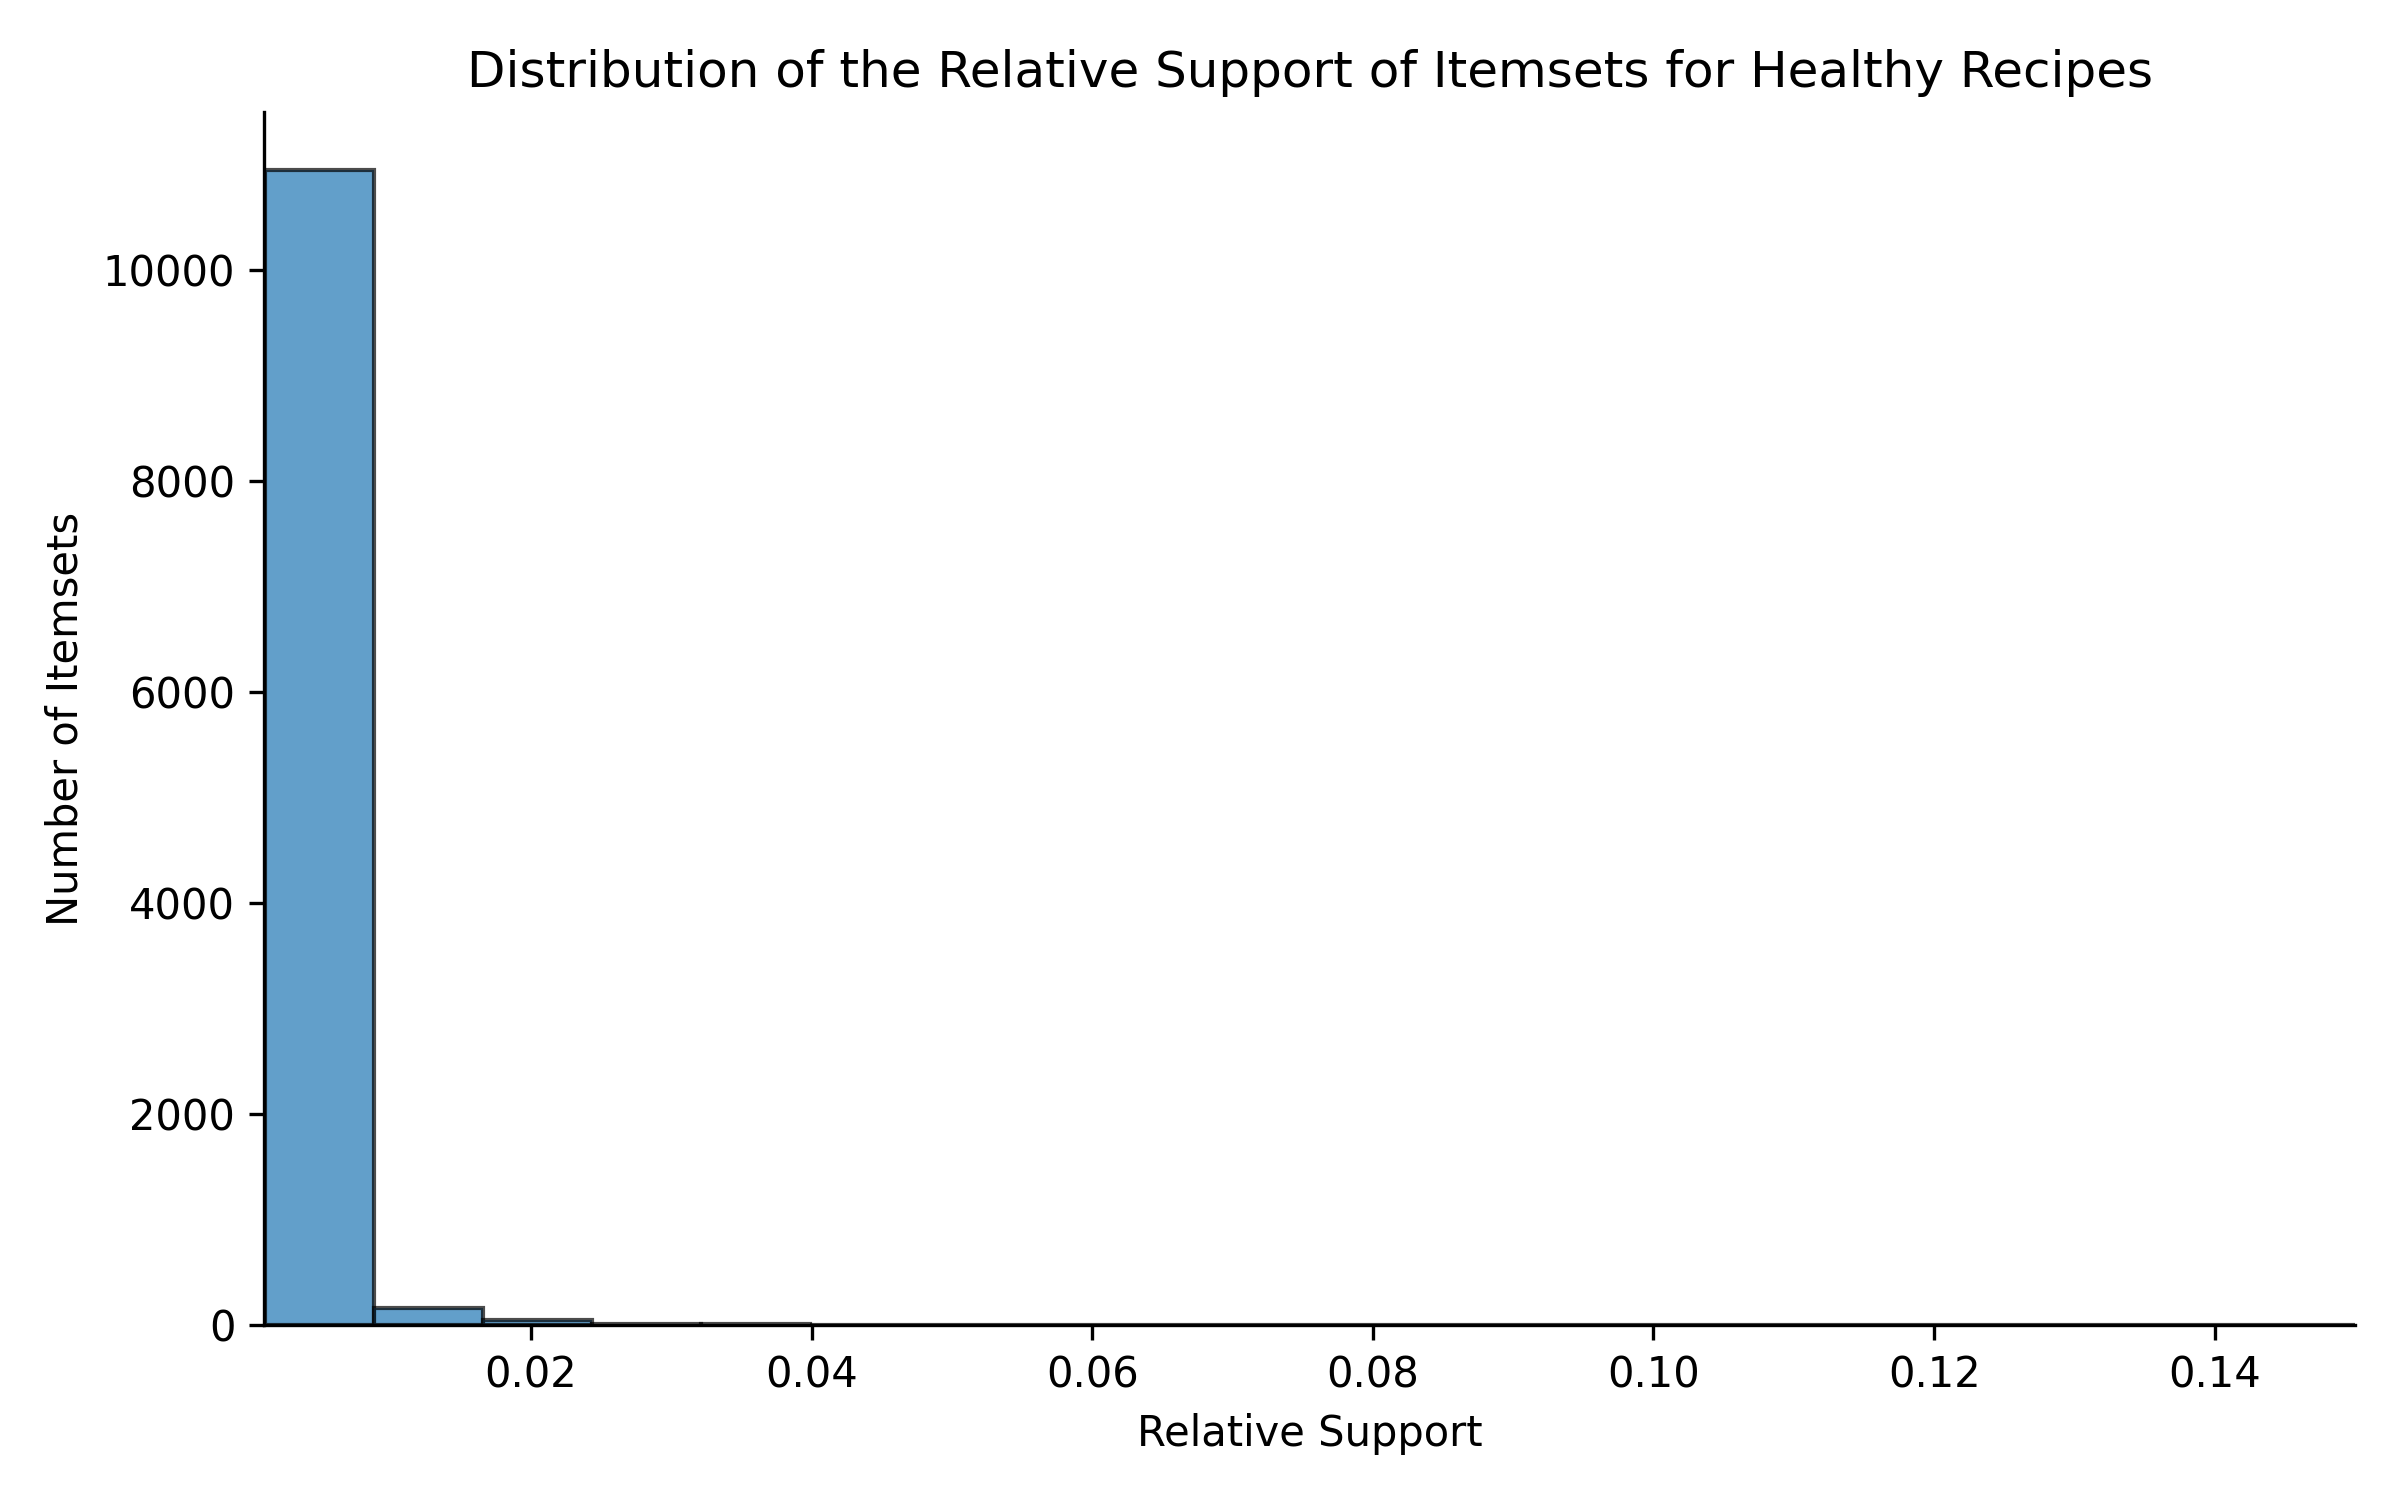

**Figure 5.** Distribution of the Relative Support of Itemsets for Healthy Recipes

In [ ]:
fig_path = 'figures/relsup_healthy.png'

if os.path.exists(fig_path):
    display(Image(fig_path))
else:
    # --- Prepare transactions (list of ingredient lists) ---
    transactions = df_healthy['ingredients'].tolist()

    # --- Set minimum support threshold ---
    min_support = 0.001  # you can adjust this

    # --- Compute absolute minimum support count ---
    minsup_count = max(1, int(len(transactions) * min_support))

    # --- Find frequent itemsets ---
    patterns = pyfpgrowth.find_frequent_patterns(transactions, minsup_count)

    # --- Convert to DataFrame ---
    itemset_freq = pd.DataFrame({
        'itemset': list(patterns.keys()),
        'count': list(patterns.values())
    })
    itemset_freq['support'] = itemset_freq['count'] / len(df_healthy)

    # --- Filter supports (optional) ---
    itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

    # --- Plot histogram ---
    plt.figure(figsize=(8, 5))
    plt.hist(itemset_freq['support'], bins=50, edgecolor='black', alpha=0.7)
    plt.title(
        "Distribution of the Relative Support of Itemsets for Healthy Recipes"
        )
    plt.xlabel("Relative Support")
    plt.ylabel("Number of Itemsets")

    # --- Adjust x-axis and layout ---
    plt.xlim(0.001, 0.15)
    plt.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.savefig(fig_path, dpi=300)
    plt.show()

display(
    Markdown(
        "**Figure 5.** Distribution of the Relative Support of "
        "Itemsets for Healthy Recipes"
    )
)

In [ ]:
# --- Parameters ---
min_support = 0.015
min_confidence = 0.75

# --- Step 1: Compute minsup count ---
num_transactions = len(df_healthy['ingredients'])
minsup_count = max(1, int(num_transactions * min_support))

# --- Step 2: Find frequent itemsets ---
freq_itemsets = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(),
    minsup_count
)

# --- Step 3: Generate association rules ---
rules = pyfpgrowth.generate_association_rules(freq_itemsets, min_confidence)

# --- Step 4: Add support & lift for each rule ---
def get_support(itemset):
    """Return support of an itemset."""
    return freq_itemsets.get(itemset, 0) / num_transactions

lifted_rules = []
for antecedent, (consequent, confidence) in rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)
    if consequent_support == 0:
        continue
    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Step 5: Sort rules by confidence (and lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Step 6A: Display top 10 frequent itemsets ---
print("=== Top 10 Frequent Itemsets (Healthy) ===")
top10_itemsets = sorted(
    freq_itemsets.items(), key=lambda x: x[1], reverse=True
)[:10]
for i, (itemset, support_count) in enumerate(top10_itemsets, start=1):
    rel_support = support_count / num_transactions
    print(f"{i}. {set(itemset)} (support = {rel_support:.3f})")


=== Top 10 Frequent Itemsets (Healthy) ===
1. {'salt'} (support = 0.390)
2. {'sugar'} (support = 0.223)
3. {'sugar', 'salt'} (support = 0.112)
4. {'salt', 'water'} (support = 0.099)
5. {'butter', 'salt'} (support = 0.075)
6. {'olive oil', 'salt'} (support = 0.072)
7. {'salt', 'onion'} (support = 0.072)
8. {'sugar', 'water'} (support = 0.065)
9. {'flour', 'salt'} (support = 0.064)
10. {'honey'} (support = 0.059)


From the FIM, 227 frequent combinations were found, and the top 10 most frequent itemsets are listed in Table 5. We see that salt also dominates as a frequent ingredient across healthy recipes. Thus, it implies that salt also acts as a universal component in healthy recipes, enhancing flavor and preserving food.

<div align="center">

| Rank | Ingredients        | Support | Relative Support |
|------|-------------------|---------|-----------------|
| 1    | (salt,)            | 17,612  | 0.389749        |
| 2    | (sugar,)           | 10,060  | 0.222625        |
| 3    | (salt, sugar)      | 5,078   | 0.112375        |
| 4    | (salt, water)      | 4,458   | 0.098655        |
| 5    | (butter, salt)     | 3,379   | 0.074776        |
| 6    | (olive oil, salt)  | 3,240   | 0.071700        |
| 7    | (onion, salt)      | 3,237   | 0.071634        |
| 8    | (sugar, water)     | 2,939   | 0.065039        |
| 9    | (flour, salt)      | 2,887   | 0.063889        |
| 10   | (honey,)           | 2,649   | 0.058622        |

**Table 5.** Top 10 Most Frequent Ingredients Combinations for Healthy Recipes

</div>

In [69]:
# Display top 10 association rules for healthy recipes
print("\n=== Top 10 Association Rules (Healthy) ===")
top10_rules = lifted_rules[:10]

for i, (antecedent, consequent, confidence, lift) in enumerate(
    top10_rules, start=1
):
    print(
        f"{i}. {set(antecedent)} -> {set(consequent)} "
        f"(confidence = {confidence:.2f}, lift = {lift:.2f})"
    )



=== Top 10 Association Rules (Healthy) ===
1. {'active dry yeast'} -> {'salt'} (confidence = 0.92, lift = 2.35)
2. {'warm water'} -> {'salt'} (confidence = 0.87, lift = 2.24)
3. {'olive oil', 'pepper'} -> {'salt'} (confidence = 0.86, lift = 2.20)
4. {'onion', 'pepper'} -> {'salt'} (confidence = 0.83, lift = 2.12)
5. {'baking powder', 'butter'} -> {'salt'} (confidence = 0.82, lift = 2.11)
6. {'sugar', 'all-purpose flour'} -> {'salt'} (confidence = 0.82, lift = 2.09)
7. {'baking powder', 'all-purpose flour'} -> {'salt'} (confidence = 0.81, lift = 2.09)
8. {'baking powder', 'milk'} -> {'salt'} (confidence = 0.79, lift = 2.03)
9. {'baking powder', 'sugar'} -> {'salt'} (confidence = 0.79, lift = 2.01)
10. {'sugar', 'baking powder', 'flour'} -> {'salt'} (confidence = 0.78, lift = 2.01)


Based on the chosen minimum support of 0.015, we generated the distribution of association rule confidence to get the optimal parameter of the minimum confidence. A minimum confidence of 0.75 was used because of similar reasoning from the previous section. Lift values were calculated to measure the strength of associations beyond random change. The top association rules for healthy recipes are listed below in Table 6.

<div align="center">

| Rank | Association Rule                                   | Confidence | Lift |
| ---- | -------------------------------------------------- | ---------- | ---- |
| 1    | {'active dry yeast'} -> {'salt'}                   | 0.92       | 2.35 |
| 2    | {'warm water'} -> {'salt'}                         | 0.87       | 2.24 |
| 3    | {'olive oil', 'pepper'} -> {'salt'}                | 0.86       | 2.20 |
| 4    | {'onion', 'pepper'} -> {'salt'}                    | 0.83       | 2.12 |
| 5    | {'baking powder', 'butter'} -> {'salt'}            | 0.82       | 2.11 |
| 6    | {'sugar', 'all-purpose flour'} -> {'salt'}         | 0.82       | 2.09 |
| 7    | {'baking powder', 'all-purpose flour'} -> {'salt'} | 0.81       | 2.09 |
| 8    | {'baking powder', 'milk'} -> {'salt'}              | 0.79       | 2.03 |
| 9    | {'baking powder', 'sugar'} -> {'salt'}             | 0.79       | 2.01 |
| 10   | {'sugar', 'baking powder', 'flour'} -> {'salt'}    | 0.78       | 2.01 |


**Table 6.** Top 10 Rules with the Highest Lift for Healthy Recipes

</div>

Similar to the non-healthy foods, the association rules highlight consistent patterns among ingredients in healthy recipes. Salt is the consequent in all rules, which confirms that it is a universal base ingredient that enhances flavor even in health-conscious recipes. The top rules show that when ingredients such as active dry yeast, warm water, olive oil, pepper, onion, butter, baking powder, sugar, all-purpose flour, or milk are present, salt is highly likely to be included as well. Confidence values ranging from 0.78 to 0.92 indicate a strong likelihood of co-occurrence, while lift values above 2 show that these associations are significantly stronger than expected by chance. Overall, these rules highlight meaningful and significant ingredient combinations in healthy recipes, emphasizing predictable and complementary patterns in flavor construction.

<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">VII. Compare, Analyze, and Interpret the Results</h1>

<div align="center">

| Rank | Non-Healthy Rule                                 | Confidence | Healthy Rule                                       | Confidence |
| ---- | ------------------------------------------------ | ---------- | -------------------------------------------------- | ---------- |
| 1    | {'butter', 'pepper'} -> {'salt'}                 | 0.83       | {'active dry yeast'} -> {'salt'}                   | 0.92       |
| 2    | {'baking soda', 'all-purpose flour'} -> {'salt'} | 0.81       | {'warm water'} -> {'salt'}                         | 0.87       |
| 3    | {'baking soda', 'sugar', 'eggs'} -> {'salt'}     | 0.81       | {'olive oil', 'pepper'} -> {'salt'}                | 0.86       |
| 4    | {'onion', 'pepper'} -> {'salt'}                  | 0.81       | {'onion', 'pepper'} -> {'salt'}                    | 0.83       |
| 5    | {'olive oil', 'pepper'} -> {'salt'}              | 0.80       | {'baking powder', 'butter'} -> {'salt'}            | 0.82       |
| 6    | {'baking powder', 'milk'} -> {'salt'}            | 0.80       | {'sugar', 'all-purpose flour'} -> {'salt'}         | 0.82       |
| 7    | {'baking soda', 'eggs'} -> {'salt'}              | 0.80       | {'baking powder', 'all-purpose flour'} -> {'salt'} | 0.81       |
| 8    | {'baking soda', 'vanilla'} -> {'salt'}           | 0.79       | {'baking powder', 'milk'} -> {'salt'}              | 0.79       |
| 9    | {'baking soda', 'brown sugar'} -> {'salt'}       | 0.78       | {'baking powder', 'sugar'} -> {'salt'}             | 0.79       |
| 10   | {'baking powder', 'sugar'} -> {'salt'}           | 0.78       | {'sugar', 'baking powder', 'flour'} -> {'salt'}    | 0.78       |


**Table 7.** Comparison of Top Association Rules in Healthy and Non-Healthy Recipes

</div>

Table 7 presents a side-by-side comparison of the top 10 association rules for non-healthy and healthy recipes. The table highlights the most frequent ingredient combinations in each category, with salt consistently appearing as the consequent in all rules. This indicates that salt is a foundational ingredient across both types of recipes. While non-healthy recipes tend to feature combinations with butter, baking soda, sugar, eggs, and other rich ingredients, healthy recipes show frequent associations with ingredients like active dry yeast, warm water, olive oil, and baking powder. Notably, some rules, such as `{'onion', 'pepper'} -> {'salt'}`, appear in both categories, suggesting certain core flavor-building patterns are common across both healthy and non-healthy dishes. Moreover, the confidence values of the top rules in healthy recipes are consistently higher than or equal to those in non-healthy recipes, indicating that these ingredient combinations are more reliably present in healthy recipes. Overall, the table emphasizes how ingredient co-occurrence patterns differ between recipe types while maintaining a consistent reliance on salt as a key flavor enhancer. To further quantify the overlap and differences in ingredient patterns between healthy and non-healthy recipes, we next measured the similarity of their frequent itemsets using the Jaccard index.

To evaluate the similarity between the frequent ingredient itemsets of all recipes and those of healthy-only recipes, we used the Jaccard index as a similarity metric. The resulting similarity score of 0.45 indicates a moderate overlap between the two groups. This suggests that while many ingredient combinations are shared, a substantial portion of frequent itemsets in healthy recipes do not appear in non-healthy recipes, highlighting differences in ingredient usage patterns. In practical terms, this highlights that although there are shared foundational ingredients, healthy recipes maintain distinctive patterns that set them apart, reflecting intentional choices in ingredient selection and combinations that support health-conscious cooking.

In [70]:
def jaccard_index(list1, list2):
    """
    Compute the Jaccard index between two lists.

    Args:
        list1 (list): First list of items.
        list2 (list): Second list of items.

    Returns:
        float: Jaccard index, the ratio of the intersection over the union.
               Returns 0 if both lists are empty.
    """
    set1 = set(list1)
    set2 = set(list2)

    # Avoid division by zero if both sets are empty
    if not set1 and not set2:
        return 0.0

    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union


# Set minimum support threshold
min_support = 0.015

# --- Frequent itemsets for non-healthy recipes ---
minsup_count = max(1, int(len(df_non_healthy) * min_support))
freq_itemsets = pyfpgrowth.find_frequent_patterns(
    df_non_healthy['ingredients'].to_list(), minsup_count
)

# --- Frequent itemsets for healthy recipes ---
minsup_count = max(1, int(len(df_healthy) * min_support))
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(), minsup_count
)

# --- Compute Jaccard similarity of frequent itemsets ---
similarity = jaccard_index(
    list(freq_itemsets.keys()), list(healthy_freq_ingredients.keys())
)
print(
    f"Jaccard Index (Healthy vs Non-Healthy Frequent Itemsets): "
    f"{similarity:.2f}"
)


Jaccard Index (Healthy vs Non-Healthy Frequent Itemsets): 0.45


Focusing specifically on the itemsets that occur exclusively in healthy recipes, which is shown in Table 8, patterns emerge that reflect healthier ingredient choices as shown in the table below. For example, vegetable oil and whole wheat flour appear in combinations that are absent from non-healthy recipes, indicating substitutions that reduce saturated fat and increase nutritional value (Das & Das, 2024). 

These findings show that healthy recipes preserve familiar flavors while prioritizing ingredients that support better nutritional profiles.

<div align="center">

| Rank | Ingredients                            | Support | Relative Support |
| ---- | -------------------------------------- | ------- | ---------------- |
| 1    | {'sugar'}                              | 10,060  | 0.222625         |
| 2    | {'vegetable oil'}                      | 2,586   | 0.057228         |
| 3    | {'flour', 'sugar'}                     | 2,124   | 0.047004         |
| 4    | {'milk', 'sugar'}                      | 1,770   | 0.039170         |
| 5    | {'eggs', 'sugar'}                      | 1,576   | 0.034877         |
| 6    | {'baking powder', 'baking soda'}       | 1,328   | 0.029388         |
| 7    | {'baking soda', 'sugar'}               | 1,216   | 0.026910         |
| 8    | {'all-purpose flour', 'baking powder'} | 1,159   | 0.025648         |
| 9    | {'whole wheat flour'}                  | 1,151   | 0.025471         |
| 10   | {'all-purpose flour', 'sugar'}         | 1,141   | 0.025250         |


**Table 8.** Frequent Ingredient Combinations that Occurred ONLY in Healthy Recipes

</div>

In [60]:
# Convert keys to sets
nonhealthy_sets = set(freq_itemsets.keys())
healthy_sets = set(healthy_freq_ingredients.keys())

# Set difference: healthy but not in non-healthy
unique_healthy_sets = healthy_sets - nonhealthy_sets

# Filter healthy_freq_ingredients to only these unique sets
unique_healthy_dict = {k: healthy_freq_ingredients[k] for k in unique_healthy_sets}

# Convert to DataFrame for easier inspection
import pandas as pd

unique_healthy_df = pd.DataFrame(
    list(unique_healthy_dict.items()), 
    columns=['ingredients', 'support']
)

# Calculate relative support
total_healthy_recipes = sum(healthy_freq_ingredients.values())  # or total number of healthy recipes
unique_healthy_df['rel_support'] = unique_healthy_df['support'] / len(df_healthy)

# Sort by support to see the most frequent unique healthy itemsets
unique_healthy_df = unique_healthy_df.sort_values(by='support', ascending=False)

# unique_healthy_df.head(10)

<a id='Recommendation'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">VIII. RECOMMENDATION & LIMITATIONS</h1>

<a id='Limitations'></a>
<h2 style="color:#ff9a00">A. Limitations of the Study</h2>

Within this study, several limitations are acknowledged. First, the data are derived from user-generated recipes, meaning that nutritional information, ingredient lists, and health-related tags are only as accurate as the contributors who entered them. This may lead to discrepancies when compared with verified nutritional data. Additionally, the classification of what constitutes a "healthy" recipe is largely determined by the platform, so tags such as "healthy" and "healthy-2" may not exactly align with standards set by nutrition experts or organizations like the DOH or WHO, particularly for elderly health.

The study also does not account for portion sizes or cooking methods. The presence of an ingredient in a recipe does not necessarily indicate the quantity used or the impact on overall nutritional content, and cooking methods such as frying or steaming can significantly alter caloric and nutrient values. While the FP-Growth algorithm is effective at identifying frequent patterns in the data, it cannot capture subtler aspects such as ingredient compatibility, culinary preferences, or consumer taste behavior.


<a id='Recommendation2'></a>
<h2 style="color:#ff9a00">B. Recommendation</h2>

From a business perspective, groceries can leverage these findings to promote healthier recipes without sacrificing flavor. Specifically, three recommendations are provided:

1. Leverage high-confidence healthy ingredient combinations for cross-merchandising. Healthy recipes consistently feature strong ingredient pairings such as `active dry yeast + salt` or `olive oil + pepper + salt`. Retailers can group these together in grocery bundles or recipe-based displays to encourage complementary purchases.

2. Avoid misleading “healthy” labeling for borderline ingredients. While these combinations appear in healthy recipes, not all components (e.g., salt, sugar, butter) are inherently healthy in large amounts. Retailers should avoid grouping or branding them collectively as “healthy” bundles, but instead promote them as “core pantry essentials.”

3. To promote healthier ingredient choices while maintaining flavor and familiarity in cooking, groceries can focus on encouraging smarter substitutions among commonly used ingredients. Highlighting natural sweeteners like honey as substitutes for sugar can preserve taste while reducing added sugars. Additionally, encouraging the use of healthier fat sources such as olive oil, in stead of butter aligns with existing patterns in healthy recipes and helps lower saturated fat without compromising texture or flavor in cooking or baking.

From a technical perspective, future studies can strengthen the analysis by integrating nutritional attributes directly into the itemset mining process. In this study, nutritional data was only used as a sanity check to verify that healthy recipes were indeed more balanced. Incorporating these attributes into the FP-Growth framework itself, such as weighting itemsets based on nutrient content, would allow the discovery of ingredient combinations that are not only frequent but also nutritionally meaningful. 


<a id='Conclusion'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">IX. CONCLUSION</h1>

This study successfully achieved its objectives of validating recipe healthiness, identifying frequent ingredient combinations in healthy recipes, and comparing them with non-healthy ones using Frequent Itemset Mining on the Food.com Recipes dataset. The first objective was achieved, as healthy recipes showed significantly lower total fat, saturated fat, and sodium, clustered in the lower range compared to non-healthy recipes, validating the filtering approach for analysis. The results revealed that healthy recipes tend to feature simpler ingredient combinations, often centered on common pantry staples, such as salt, sugar, water, olive oil, onion, butter, and honey, while maintaining distinct co-occurrence patterns from non-healthy recipes, with only about 45% overlap in frequent itemsets. Salt consistently appeared as the consequent in both healthy and non-healthy association rules, reaffirming its universal role as a flavor enhancer across all dishes. Common association rules in healthy recipes include `{'active dry yeast'} -> {'salt'}`, `{'warm water'} -> {'salt'}`, and `{'olive oil', 'pepper'} -> {'salt'}`, highlighting frequent pairings that reliably appear together. Notably, the healthy recipes demonstrated generally higher or equal confidence levels in their association rules, suggesting more consistent and reliable ingredient pairings. These findings not only highlight the key ingredients that define healthy cooking but also provide practical insights for grocery retailers and nutrition advocates in promoting ingredient combinations that support healthy, accessible, and flavorful meals.

<a id='References'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">ACKNOWLEDGEMENTS</h1>

The team would like to acknowledge Food.com as the original source of the reviews and the Asian Institute of Management's "jojie-collected" repository for compiling and sharing the food-com-recipes dataset for public educational use. They would like to express their sincere appreciation to their learning team members and Professor Christian M. Alis for their invaluable guidance and support in completing this report. The group also acknowledges their use of Artificial Intelligence, such as ChatGPT. 


<a id='References'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">REFERENCES</h1>

<ul style="list-style-type:none; padding-left:0;">
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    American Heart Association. (2024, August 23). Dietary Fats. Dietary Fats. <br>
    Retrieved November 11, 2025, from <a href="https://www.heart.org/en/healthy-living/healthy-eating/eat-smart/fats/dietary-fats">https://www.heart.org/en/healthy-living/healthy-eating/eat-smart/fats/dietary-fats</a>
  </li>
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Das, M., Das, A. A comprehensive review on strategies for replacing saturated fats in bakery products. Discov Food 4, 156 (2024). <br>
    <a href="https://doi.org/10.1007/s44187-024-00240-2">https://doi.org/10.1007/s44187-024-00240-2</a>
  </li>
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Dietary Guidelines for Americans. (2025). Make Every Bite Count With the Dietary Guidelines. <br>
    Retrieved November 11, 2025, from <a href="https://www.dietaryguidelines.gov/sites/default/files/2020-12/Dietary_Guidelines_for_Americans_2020-2025.pdf">https://www.dietaryguidelines.gov/sites/default/files/2020-12/Dietary_Guidelines_for_Americans_2020-2025.pdf</a>
  </li>
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Stein, E. C., Stowers, K. C., McCabe, M. L., White, M. A., & Schwartz, M. B. (2019). Ingredient bundles and recipe tastings in food pantries: a pilot study to increase the selection of healthy foods. Public Health Nutrition, 22(09), 1717–1722. <br>
    <a href="https://doi.org/10.1017/s1368980019000259">https://doi.org/10.1017/s1368980019000259</a>
  </li>
</ul>


***
**END**